# 02 · ATL13 QC — what does ICESat-2 show over Kakhovka?

Reads `pass_levels.parquet`. `scripts/build_findings.py` turns this into `outputs/reports/atl13_v1_findings.md`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'src'))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from kakhovka_altimetry.config import load_config
from kakhovka_altimetry.io import read_parquet
cfg = load_config()


In [2]:
passes = read_parquet(cfg.pass_levels_parquet)
passes['date'] = pd.to_datetime(passes['datetime']).dt.date
ok = passes[passes['qc_pass']]
print(len(passes), 'passes;', len(ok), 'QC-ok;', passes['transect'].nunique(), 'transects')
passes.groupby('year')['qc_pass'].agg(total='size', ok='sum')

1680 passes; 1138 QC-ok; 102 transects


,total,ok
year,,
2018,40,37
2019,246,227
2020,258,229
2021,219,181
2022,222,184
2023,243,133
2024,220,78
2025,232,69


In [3]:
passes.loc[~passes['qc_pass'], 'qc_flags'].pipe(lambda s: s[s.str.len()>0]).str.get_dummies('|').sum().sort_values(ascending=False)

slope_too_steep    250
too_few_points     244
range_too_large    189
track_too_short     86
mad_too_large       74
stdev_too_large     26
dtype: int64

### Points per pass, within-pass spread

Text(0.5, 1.0, 'within-pass range p95-p05 (m)')

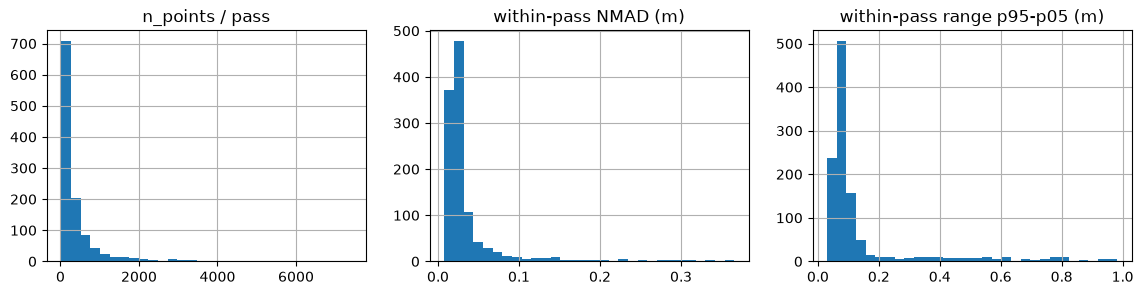

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3))
ok['n_points'].hist(ax=ax[0], bins=30); ax[0].set_title('n_points / pass')
ok['nmad_m'].hist(ax=ax[1], bins=30); ax[1].set_title('within-pass NMAD (m)')
ok['range_m'].hist(ax=ax[2], bins=30); ax[2].set_title('within-pass range p95-p05 (m)')

### One pass: along-track water-surface profile

Text(0.5, 1.0, '2019-03-17 18:05:09.522858496+00:00')

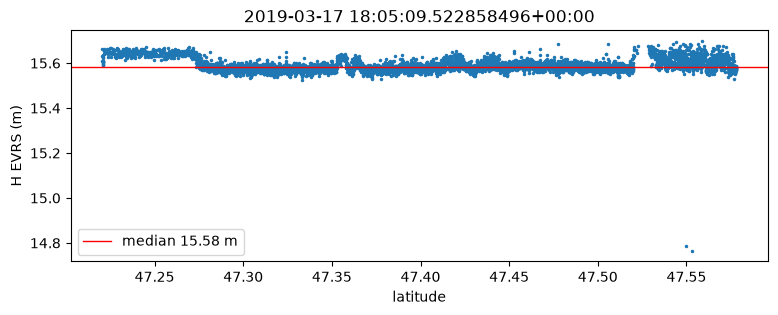

In [5]:
evrs = read_parquet(cfg.evrs_parquet)
key = ok.sort_values('n_points').iloc[-1]
seg = evrs[(pd.to_datetime(evrs['time']).dt.date == key['date'])
          & (evrs['rgt'] == key['rgt']) & (evrs.get('beam') == key['beam'])]
lbl = 'median {:.2f} m'.format(key['median_wse_evrs_m'])
plt.figure(figsize=(9,3))
plt.plot(seg['lat'], seg['H_evrs_egg2015_m'], '.', ms=3)
plt.axhline(key['median_wse_evrs_m'], color='r', lw=1, label=lbl)
plt.xlabel('latitude'); plt.ylabel('H EVRS (m)'); plt.legend(); plt.title(str(key['datetime']))

### Beam agreement (same date + RGT)

In [6]:
be = ok.groupby(['date','rgt'])['median_wse_evrs_m'].agg(n='size', spread=lambda v: v.max()-v.min())
be = be[be['n'] > 1]
print('multi-beam overpasses:', len(be)); be['spread'].describe()

multi-beam overpasses: 229


count    229.000000
mean       0.165123
std        0.528725
min        0.003713
25%        0.050062
50%        0.069864
75%        0.097565
max        6.948178
Name: spread, dtype: float64